<a href="https://colab.research.google.com/github/GustavoFA/IA376/blob/main/A1/236249_a1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA376 — Deep Generative Modeling

## A1 — Building a Model for the Synthesis of Tabular Healthcare Data

Gustavo Freitas Alves

236249

### Imports

In [63]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import norm, ks_2samp

#### Getting the clinical laboratory test results (in json extension)

In [2]:
!pip install -q gdown

In [3]:
!gdown 1t_2rnFzTUDS851VgfgPutB2pPUSEo_0e

Downloading...
From: https://drive.google.com/uc?id=1t_2rnFzTUDS851VgfgPutB2pPUSEo_0e
To: /content/data.json
100% 10.2M/10.2M [00:00<00:00, 72.8MB/s]


In [4]:
with open('data.json', 'r') as f:
  data = json.load(f)

## Exploring blood data

In [10]:
exam_counter = Counter()

In [11]:
for patient in data.values():
  exams = patient['exams']
  exam_counter.update(exams.keys())
print(f'Number of exams: {len(exam_counter)}')

Number of exams: 17


In [12]:
exam_df = pd.DataFrame(
    exam_counter.items(),
    columns=['exam', 'count']
)
exam_df = exam_df.sort_values(by='count', ascending=False)
exam_df.head(30)

,exam,count
0,PLAQUETAS SANGUE,30912
1,NEUTRÓFILOS ABSOLUTO,30912
2,LINFÓCITOS ABSOLUTO,30912
4,LINFÓCITOS %,30912
3,NEUTRÓFILOS %,30872
5,LEUCÓCITOS TOTAIS,216
6,MCHC,216
7,EOSINÓFILOS ABSOLUTO,216
8,LUC ABSOLUTO,216
9,NEUTRÓFILOS SEGMENTADOS %,216


So, in the table above we can see that the most common exams are *PLAQUETAS SANGUE*, *NEUTRÓFILOS ABSOLUTO*, *LINFÓCITOS ABSOLUTO*, *LINFÓCITOS*,
*NEUTRÓFILOS* and *LEUCÓCITOS TOTAIS*.

For this activity I'll use the **PLAQUETAS SANGUE** data for generate synthetic database.

## Generate a synthetic database using normal distribution

### Selecting data exam

In [13]:
exam_choice = "PLAQUETAS SANGUE"

In [19]:
exam_values = [patient['exams'][exam_choice] for patient in data.values() if exam_choice in patient['exams']]

In [21]:
samples_db = pd.DataFrame({f"{exam_choice.lower()}": exam_values})
samples_db.head()

,plaquetas sangue
0,282.0
1,377.0
2,300.0
3,215.0
4,359.0


In [22]:
print(f'Number of samples in database: {len(samples_db)}')

Number of samples in database: 30912


### Cleaning data

Remove missing values

In [24]:
samples_db_cleaned = samples_db.dropna()
print(f'Number of samples in database after removing missing values: {len(samples_db_cleaned)}')

Number of samples in database after removing missing values: 30907


Remove negatives values (for this exam it's impossible)

In [50]:
# samples_db_cleaned = samples_db_cleaned[samples_db_cleaned[exam_choice.lower()] > 0]
# print(f'Number of samples in database after removing impossible values: {len(samples_db_cleaned)}')

Remove extreme outliers using Interquartile range method (IQR).

In [28]:
q1 = samples_db_cleaned[exam_choice.lower()].quantile(0.25)
q3 = samples_db_cleaned[exam_choice.lower()].quantile(0.75)

In [29]:
iqr = q3 - q1

In [30]:
iqr_lower = q1 - 1.5 * iqr
iqr_upper = q3 + 1.5 * iqr

In [31]:
samples_db_cleaned = samples_db_cleaned[(samples_db_cleaned[exam_choice.lower()] > iqr_lower) & (samples_db_cleaned[exam_choice.lower()] < iqr_upper)]
print(f'Number of samples in database after removing outliers: {len(samples_db_cleaned)}')

Number of samples in database after removing outliers: 29711


In [32]:
samples_db = samples_db_cleaned

### Analysing filtered data

In [38]:
samples_db.describe()

,plaquetas sangue
count,29711.000000
mean,241.520171
std,78.998385
min,30.000000
25%,190.000000
50%,238.000000
75%,292.000000
max,460.000000


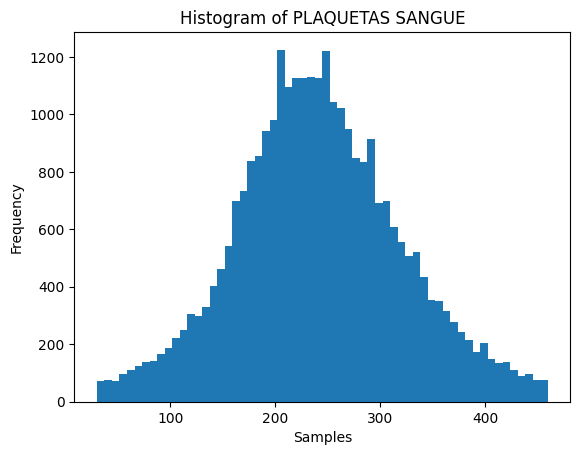

In [48]:
plt.hist(samples_db[exam_choice.lower()], bins=60)
plt.title(f"Histogram of {exam_choice}")
plt.ylabel("Frequency")
plt.xlabel("Samples")
plt.show()

### Fitting data

In [51]:
mu, sigma = norm.fit(samples_db[exam_choice.lower()])

In [54]:
x = np.linspace(samples_db[exam_choice.lower()].min(), samples_db[exam_choice.lower()].max(), 200)
pdf = norm.pdf(x, mu, sigma)

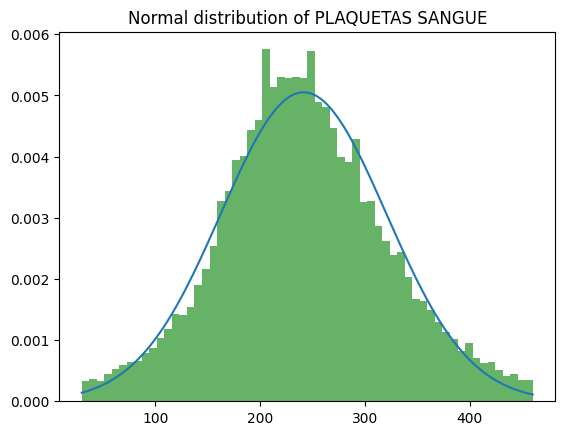

In [55]:
plt.hist(samples_db[exam_choice.lower()], bins=60, density=True, alpha=0.6, color='g')
plt.plot(x, pdf)
plt.title(f"Normal distribution of {exam_choice}")
plt.show()

### Generate synthetic data

Generate synthetic database following the normal distribution

In [56]:
synthetic_database = np.random.normal(mu, sigma, 1000)

Check if there is unrealistic values

In [57]:
synthetic_database = np.clip(
    synthetic_database,
    samples_db[exam_choice.lower()].min(),
    samples_db[exam_choice.lower()].max()
)

Create the final synthetic database

In [59]:
synthetic_database = pd.DataFrame({f"{exam_choice.lower()}": synthetic_database})

In [60]:
print(f'Number of samples in synthetic database: {len(synthetic_database)}')

Number of samples in synthetic database: 1000


### Compare real and synthetic data

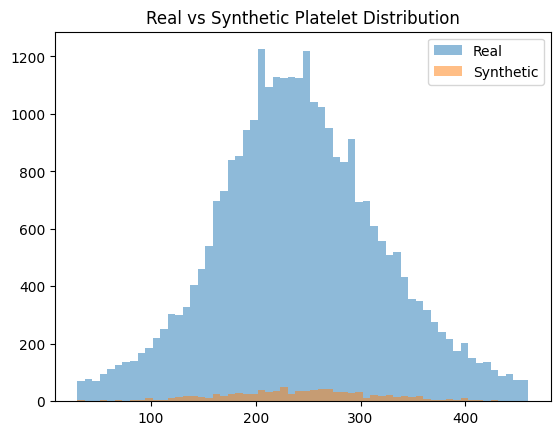

In [62]:
plt.hist(samples_db[exam_choice.lower()], bins=60, alpha=0.5, label="Real")
plt.hist(synthetic_database, bins=60, alpha=0.5, label="Synthetic")

plt.legend()
plt.title("Real vs Synthetic Platelet Distribution")
plt.show()

In [66]:
print(f'Real data mean: {samples_db[exam_choice.lower()].mean():.2f}')
print(f'Real data std: {samples_db[exam_choice.lower()].std():.2f}')
print(f'Synthetic data mean: {synthetic_database[exam_choice.lower()].mean():.2f}')
print(f'Synthetic data std: {synthetic_database[exam_choice.lower()].std():.2f}')

Real data mean: 241.52
Real data std: 79.00
Synthetic data mean: 242.49
Synthetic data std: 75.40


In [67]:
ks_stat, p_value = ks_2samp(samples_db[exam_choice.lower()], synthetic_database[exam_choice.lower()])
print(f'KS Statistic: {ks_stat:.2f}')
print(f'P-value: {p_value:.2f}')

KS Statistic: 0.04
P-value: 0.14


### Is synthetic data realistic?

Considering the results from ...